11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


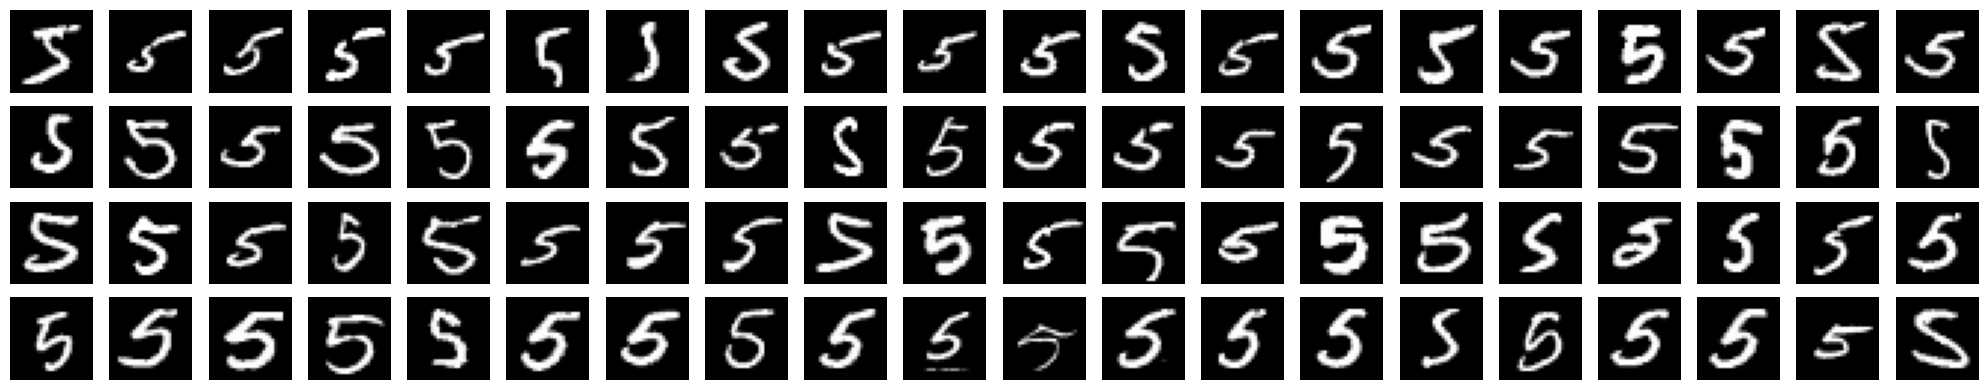

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# MNISTをNumPy配列として読み込み
(x_train, y_train), (_, _) = mnist.load_data()

# 「5」のインデックスを取得
five_indices = np.where(y_train == 5)[0]

# 表示枚数（4×20 = 80）
num_rows = 4
num_cols = 20
num_images = num_rows * num_cols

plt.figure(figsize=(20, 4))
for i, idx in enumerate(five_indices[:num_images]):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.axis("off")

# plt.suptitle("MNIST - Label 5 (4 x 20)", fontsize=16)
plt.tight_layout()
plt.show()

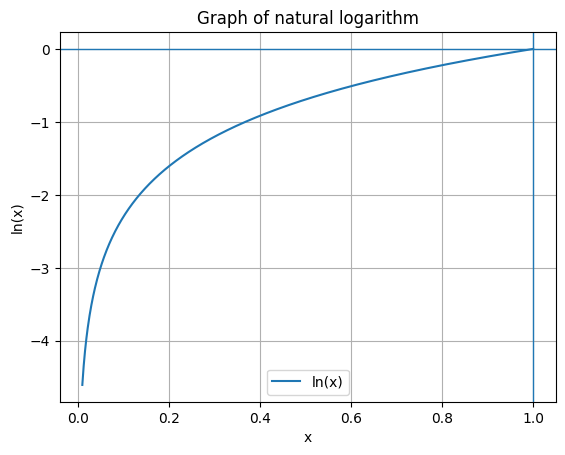

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ln(x) は x>0 なので、0より大きい範囲を用意
x = np.linspace(0.01, 1, 1000)
y = np.log(x)  # 自然対数 ln(x)

plt.figure()
plt.plot(x, y, label="ln(x)")
plt.axhline(0, linewidth=1)  # y=0 の線
plt.axvline(1, linewidth=1)  # x=1 の線（ln(1)=0）
plt.xlabel("x")
plt.ylabel("ln(x)")
plt.title("Graph of natural logarithm")
plt.grid(True)
plt.legend()
plt.show()


In [1]:
import sys,os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test)=\
  load_mnist(normalize=True, one_hot_label=True)
  
print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


### 二乗和誤差（Mean Squared Error）

バッチサイズを $B$、  
モデル出力（softmax後）を $\mathbf{y}_i \in \mathbb{R}^K$、  
正解ラベル（one-hot）を $\mathbf{t}_i \in \mathbb{R}^K$ とすると、

$$
\mathcal{L}_{\mathrm{MSE}}
= \frac{1}{2B}
\sum_{i=1}^{B}
\sum_{k=1}^{K}
\left( y_{ik} - t_{ik} \right)^2
$$

### 交差エントロピー誤差（Cross Entropy Error）

$$
\mathcal{L}_{\mathrm{CE}}
= -\frac{1}{B}
\sum_{i=1}^{B}
\sum_{k=1}^{K}
t_{ik} \log \left( y_{ik} \right)
$$


In [5]:
import numpy as np
from sklearn.datasets import fetch_openml

np.set_printoptions(precision=4, suppress=True)

# -------------------------
# utility
# -------------------------
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def one_hot(labels, num_classes=10):
    return np.eye(num_classes)[labels.astype(int)]

# サンプルごとのMSE
def mse_per_sample(y, t):
    return 0.5 * np.sum((y - t) ** 2, axis=1)

# サンプルごとのCEE
def cee_per_sample(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta), axis=1)

# -------------------------
# load MNIST
# -------------------------
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.to_numpy() / 255.0
y = mnist.target.astype(int).to_numpy()

# -------------------------
# mini-batch
# -------------------------
batch_size = 8  # あえて小さく
idx = np.random.choice(len(X), batch_size, replace=False)
x_batch = X[idx]
t_batch = one_hot(y[idx])

# -------------------------
# dummy model
# -------------------------
W = np.random.randn(784, 10) * 0.01
b = np.zeros(10)

scores = x_batch @ W + b
y_batch = softmax(scores)

# -------------------------
# loss
# -------------------------
mse_losses = mse_per_sample(y_batch, t_batch)
cee_losses = cee_per_sample(y_batch, t_batch)

# -------------------------
# output
# -------------------------
print("=== Per-sample comparison ===")
for i in range(batch_size):
    true_label = y[idx[i]]
    pred_label = np.argmax(y_batch[i])
    print(
        f"[{i}] true={true_label}, pred={pred_label} | "
        f"MSE={mse_losses[i]:.4f}, CEE={cee_losses[i]:.4f}"
    )

print("\n=== Batch statistics ===")
print(f"MSE  mean : {mse_losses.mean():.4f}")
print(f"MSE  max  : {mse_losses.max():.4f}")
print(f"CEE  mean : {cee_losses.mean():.4f}")
print(f"CEE  max  : {cee_losses.max():.4f}")

print("\n=== Contribution ratio (largest / mean) ===")
print(f"MSE : {mse_losses.max() / mse_losses.mean():.2f}")
print(f"CEE : {cee_losses.max() / cee_losses.mean():.2f}")

=== Per-sample comparison ===
[0] true=5, pred=7 | MSE=0.4492, CEE=2.2928
[1] true=1, pred=8 | MSE=0.4428, CEE=2.2314
[2] true=7, pred=3 | MSE=0.4479, CEE=2.2804
[3] true=5, pred=4 | MSE=0.4602, CEE=2.4053
[4] true=8, pred=0 | MSE=0.4631, CEE=2.4400
[5] true=0, pred=0 | MSE=0.4279, CEE=2.0975
[6] true=3, pred=3 | MSE=0.4387, CEE=2.1924
[7] true=7, pred=3 | MSE=0.4568, CEE=2.3678

=== Batch statistics ===
MSE  mean : 0.4483
MSE  max  : 0.4631
CEE  mean : 2.2885
CEE  max  : 2.4400

=== Contribution ratio (largest / mean) ===
MSE : 1.03
CEE : 1.07


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# sigmoid とその微分
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

# 描画関数
def plot_sigmoid_tangent(x0):
    x = np.linspace(-10, 10, 400)
    y = sigmoid(x)

    y0 = sigmoid(x0)
    slope = sigmoid_grad(x0)
    tangent = slope * (x - x0) + y0

    plt.figure(figsize=(7, 4))
    plt.plot(x, y, label="sigmoid", linewidth=2)
    plt.plot(x, tangent, "--", label="tangent", linewidth=2)
    plt.scatter([x0], [y0], color="red", zorder=3)

    plt.title(f"Sigmoid and Tangent at x0 = {x0:.2f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.legend()
    plt.show()

# スライダー
interact(
    plot_sigmoid_tangent,
    x0=FloatSlider(min=-8, max=8, step=0.1, value=0)
)


interactive(children=(FloatSlider(value=0.0, description='x0', max=8.0, min=-8.0), Output()), _dom_classes=('w…

<function __main__.plot_sigmoid_tangent(x0)>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ステップ関数
def step_function(x):
    return (x >= 0).astype(float)

# 描画
def plot_step_tangent(x0):
    x = np.linspace(-10, 10, 400)
    y = step_function(x)

    y0 = step_function(np.array([x0]))[0]

    # 「接線」：ほぼ全域で勾配0
    slope = 0.0
    tangent = slope * (x - x0) + y0

    plt.figure(figsize=(7, 4))
    plt.plot(x, y, label="step function", linewidth=2)
    plt.plot(x, tangent, "--", label="pseudo tangent (slope=0)", linewidth=2)
    plt.scatter([x0], [y0], color="red", zorder=3)

    # 不連続点の強調
    plt.axvline(0, color="gray", linestyle=":", alpha=0.7)
    plt.text(0.05, 0.5, "non-differentiable", rotation=90, color="gray")

    plt.title(f"Step Function (x0 = {x0:.2f})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.legend()
    plt.show()

# スライダー
interact(
    plot_step_tangent,
    x0=FloatSlider(min=-8, max=8, step=0.1, value=0)
)


interactive(children=(FloatSlider(value=0.0, description='x0', max=8.0, min=-8.0), Output()), _dom_classes=('w…

<function __main__.plot_step_tangent(x0)>

# ch04/gradient_1d.py

数値微分を使って関数の接線を求め、グラフに描画します。
`numerical_diff`関数は、中心差分を用いて微分の近似値を計算します。
`function_1`は $y = 0.01x^2 + 0.1x$ という関数です。
`tangent_line`関数は、指定された点における接線を求めます。

0.1999999999990898


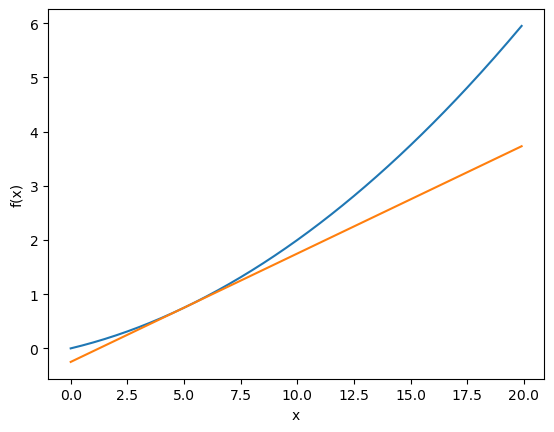

In [1]:
import numpy as np
import matplotlib.pylab as plt


def numerical_diff(f, x):
    h = 1e-4 # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)


def function_1(x):
    return 0.01*x**2 + 0.1*x 


def tangent_line(f, x):
    d = numerical_diff(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y
     
x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")

tf = tangent_line(function_1, 5)
y2 = tf(x)

plt.plot(x, y)
plt.plot(x, y2)
plt.show()


# ch04/gradient_2d.py

勾配を求める関数`numerical_gradient`を実装します。
この関数は、各変数に対する偏微分をまとめてベクトル（勾配）として返します。
また、$f(x_0, x_1) = x_0^2 + x_1^2$ の勾配をベクトル場としてプロットし、勾配が関数の最小値を指していることを確認します。

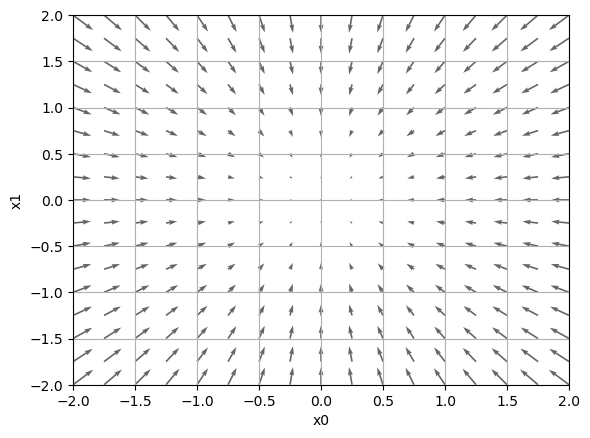

In [2]:
# cf.http://d.hatena.ne.jp/white_wheels/20100327/p3
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D


def _numerical_gradient_no_batch(f, x):
    h = 1e-4  # 0.0001
    grad = np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)  # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x)  # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val  # 値を元に戻す
        
    return grad


def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)
        
        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        
        return grad


def function_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)


def tangent_line(f, x):
    d = numerical_gradient(f, x)
    print(d)
    y = f(x) - d*x
    return lambda t: d*t + y


if __name__ == '__main__':
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)
    
    X = X.flatten()
    Y = Y.flatten()

    grad = numerical_gradient(function_2, np.array([X, Y]).T).T

    plt.figure()
    plt.quiver(X, Y, -grad[0], -grad[1],  angles="xy",color="#666666")
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.grid()
    plt.draw()
    plt.show()

# ch04/gradient_method.py

勾配降下法を行う`gradient_descent`関数を実装します。
この関数を使って、$f(x_0, x_1) = x_0^2 + x_1^2$ の最小値を探索する過程をプロットします。
学習率（`lr`）やステップ数（`step_num`）を指定して更新を行います。

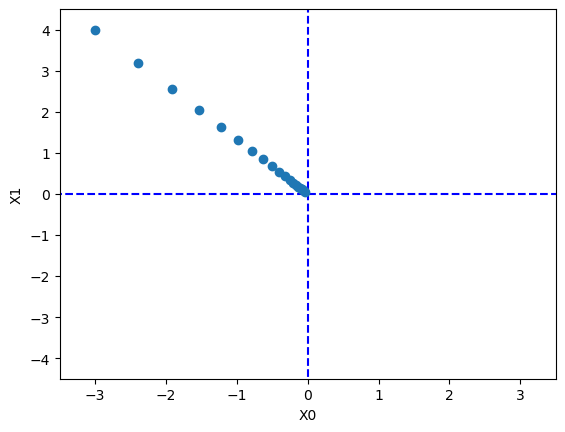

In [3]:
import numpy as np
import matplotlib.pylab as plt


def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append( x.copy() )

        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)


def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])    

lr = 0.1
step_num = 20
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)

plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()

# ch04/gradient_simplenet.py

シンプルなニューラルネットワーク`simpleNet`クラスを実装します。
$2 \times 3$ の重み行列`W`を持ちます。
`predict`メソッドで予測を行い、`loss`メソッドで損失（交差エントロピー誤差）を計算します。
`numerical_gradient`を使って、損失関数の重みに対する勾配を求めます。

In [4]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient


class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

x = np.array([0.6, 0.9])
t = np.array([0, 0, 1])

net = simpleNet()

f = lambda w: net.loss(x, t)
dW = numerical_gradient(f, net.W)

print(dW)

[[ 0.17576655  0.225064   -0.40083055]
 [ 0.26364982  0.337596   -0.60124582]]


# ch04/two_layer_net.py

2層ニューラルネットワーク`TwoLayerNet`クラスを実装します。
隠れ層と出力層を持ち、重みとバイアスの初期化、予測（`predict`）、損失計算（`loss`）、認識精度計算（`accuracy`）を行います。
`numerical_gradient`メソッドは数値微分によって勾配を計算し、`gradient`メソッドは誤差逆伝播法（後述の章で解説）によって高速に勾配を計算します。

In [5]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
from common.functions import *
from common.gradient import numerical_gradient
import numpy as np


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
    
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        return y
        
    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)
        
        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
        
    # x:入力データ, t:教師データ
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)
        
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads
        
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}
        
        batch_num = x.shape[0]
        
        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)
        
        dz1 = np.dot(dy, W2.T)
        da1 = sigmoid_grad(a1) * dz1
        grads['W1'] = np.dot(x.T, da1)
        grads['b1'] = np.sum(da1, axis=0)

        return grads

# ch04/train_neuralnet.py

MNISTデータセットを使って、`TwoLayerNet`の学習を行います。
ミニバッチ学習を実装し、指定した繰り返し回数（`iters_num`）だけパラメータの更新を行います。
1エポックごとに訓練データとテストデータに対する認識精度を計算し、学習の推移をグラフに描画します。

train acc, test acc | 0.09863333333333334, 0.0958
train acc, test acc | 0.7892666666666667, 0.7947
train acc, test acc | 0.8764, 0.8811
train acc, test acc | 0.8979833333333334, 0.9005
train acc, test acc | 0.9075166666666666, 0.91
train acc, test acc | 0.9144166666666667, 0.9168
train acc, test acc | 0.9195666666666666, 0.9212
train acc, test acc | 0.9248166666666666, 0.926
train acc, test acc | 0.9273333333333333, 0.9288
train acc, test acc | 0.9308833333333333, 0.9329
train acc, test acc | 0.9342666666666667, 0.9349
train acc, test acc | 0.9372666666666667, 0.9375
train acc, test acc | 0.9393333333333334, 0.9388
train acc, test acc | 0.9424, 0.9417
train acc, test acc | 0.9439333333333333, 0.9428
train acc, test acc | 0.9453833333333334, 0.9442
train acc, test acc | 0.94705, 0.9465


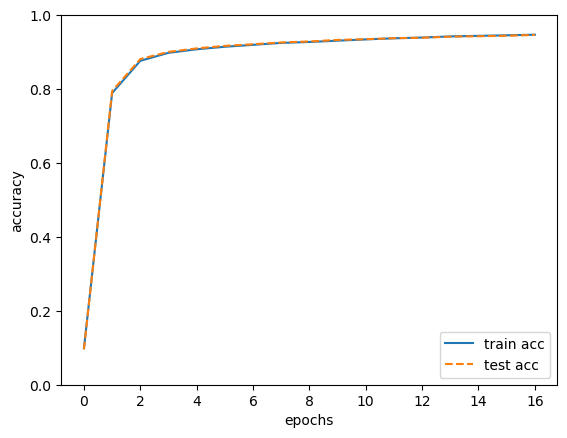

In [6]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000  # 繰り返しの回数を適宜設定する
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 勾配の計算
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)
    
    # パラメータの更新
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

# グラフの描画
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()